In [1]:
# Enhanced Decision Tree with Friendly Visualization
# Based on diabetes prediction dataset - VERSION OPTIMIZADA

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn import metrics
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

# Set style for better looking plots
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")


In [2]:
################################# DATA HANDLING ####################################################
col_names = ['pregnant', 'glucose', 'bp', 'skin', 'insulin', 'bmi', 'pedigree', 'age', 'label']
# load dataset
pima = pd.read_csv("diabetes.csv", header=None, names=col_names)

# Create more readable feature names for visualization
feature_mapping = {
    'pregnant': 'Pregnancies',
    'insulin': 'Insulin Level',
    'bmi': 'BMI',
    'age': 'Age',
    'glucose': 'Glucose Level',
    'bp': 'Blood Pressure',
    'pedigree': 'Diabetes Pedigree'
}

feature_cols = ['pregnant', 'insulin', 'bmi', 'age', 'glucose', 'bp', 'pedigree']

################################# LIMPIEZA DE DATOS ####################################################
# En este dataset, valores de 0 en estas columnas son biologicamente imposibles
# (nadie tiene presion arterial, glucosa o BMI de 0), por lo que en realidad
# representan datos faltantes codificados como cero.
cols_con_ceros_invalidos = ['glucose', 'bp', 'skin', 'insulin', 'bmi']

print("Porcentaje de ceros (datos faltantes) por columna:")
for col in cols_con_ceros_invalidos:
    pct = (pima[col] == 0).mean() * 100
    print(f"  {col}: {pct:.1f}%")

# Reemplazamos 0 por NaN y luego imputamos con la mediana (mas robusta ante outliers que la media)
pima[cols_con_ceros_invalidos] = pima[cols_con_ceros_invalidos].replace(0, np.nan)
pima[cols_con_ceros_invalidos] = pima[cols_con_ceros_invalidos].fillna(pima[cols_con_ceros_invalidos].median())

X = pima[feature_cols]
y = pima.label

print(f"\nDistribucion de clases:\n{y.value_counts()}")
print(f"Porcentaje clase positiva (diabetes): {y.mean():.1%}")

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=1, stratify=y)


Porcentaje de ceros (datos faltantes) por columna:
  glucose: 0.7%
  bp: 4.6%
  skin: 29.6%
  insulin: 48.7%
  bmi: 1.4%

Distribucion de clases:
label
0    500
1    268
Name: count, dtype: int64
Porcentaje clase positiva (diabetes): 34.9%


In [3]:
################################# MACHINE LEARNING PART ####################################################
# En vez de crear el arbol con parametros por defecto (lo que suele sobreajustar),
# buscamos la mejor combinacion de hiperparametros con validacion cruzada.
# class_weight='balanced' compensa el desbalance de clases (65% / 35%).

param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [3, 4, 5, 6, 7, 8, None],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 5, 10, 20],
    'class_weight': [None, 'balanced']
}

grid_search = GridSearchCV(
    DecisionTreeClassifier(random_state=1),
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)
grid_search.fit(X_train, y_train)

print("Mejores hiperparametros encontrados:")
for param, value in grid_search.best_params_.items():
    print(f"  {param}: {value}")
print(f"\nAccuracy promedio en validacion cruzada (train): {grid_search.best_score_:.2%}")

clf = grid_search.best_estimator_

# Predictions and accuracy en el set de prueba
y_pred = clf.predict(X_test)
accuracy = metrics.accuracy_score(y_test, y_pred)
print(f"\nModel Accuracy (test set): {accuracy:.2%}")


Mejores hiperparametros encontrados:
  class_weight: None
  criterion: gini
  max_depth: 6
  min_samples_leaf: 20
  min_samples_split: 2

Accuracy promedio en validacion cruzada (train): 75.98%

Model Accuracy (test set): 74.46%


In [4]:
################################# VALIDACION CRUZADA ####################################################
# Una sola division train/test puede dar una estimacion optimista o pesimista por azar.
# cross_val_score sobre todo el dataset da una estimacion mas confiable del desempeno real.

cv_scores = cross_val_score(clf, X, y, cv=5, scoring='accuracy')
print(f"Accuracy por fold: {[f'{s:.2%}' for s in cv_scores]}")
print(f"Accuracy promedio: {cv_scores.mean():.2%} (+/- {cv_scores.std():.2%})")


Accuracy por fold: ['77.27%', '69.48%', '77.27%', '79.74%', '73.20%']
Accuracy promedio: 75.39% (+/- 3.63%)


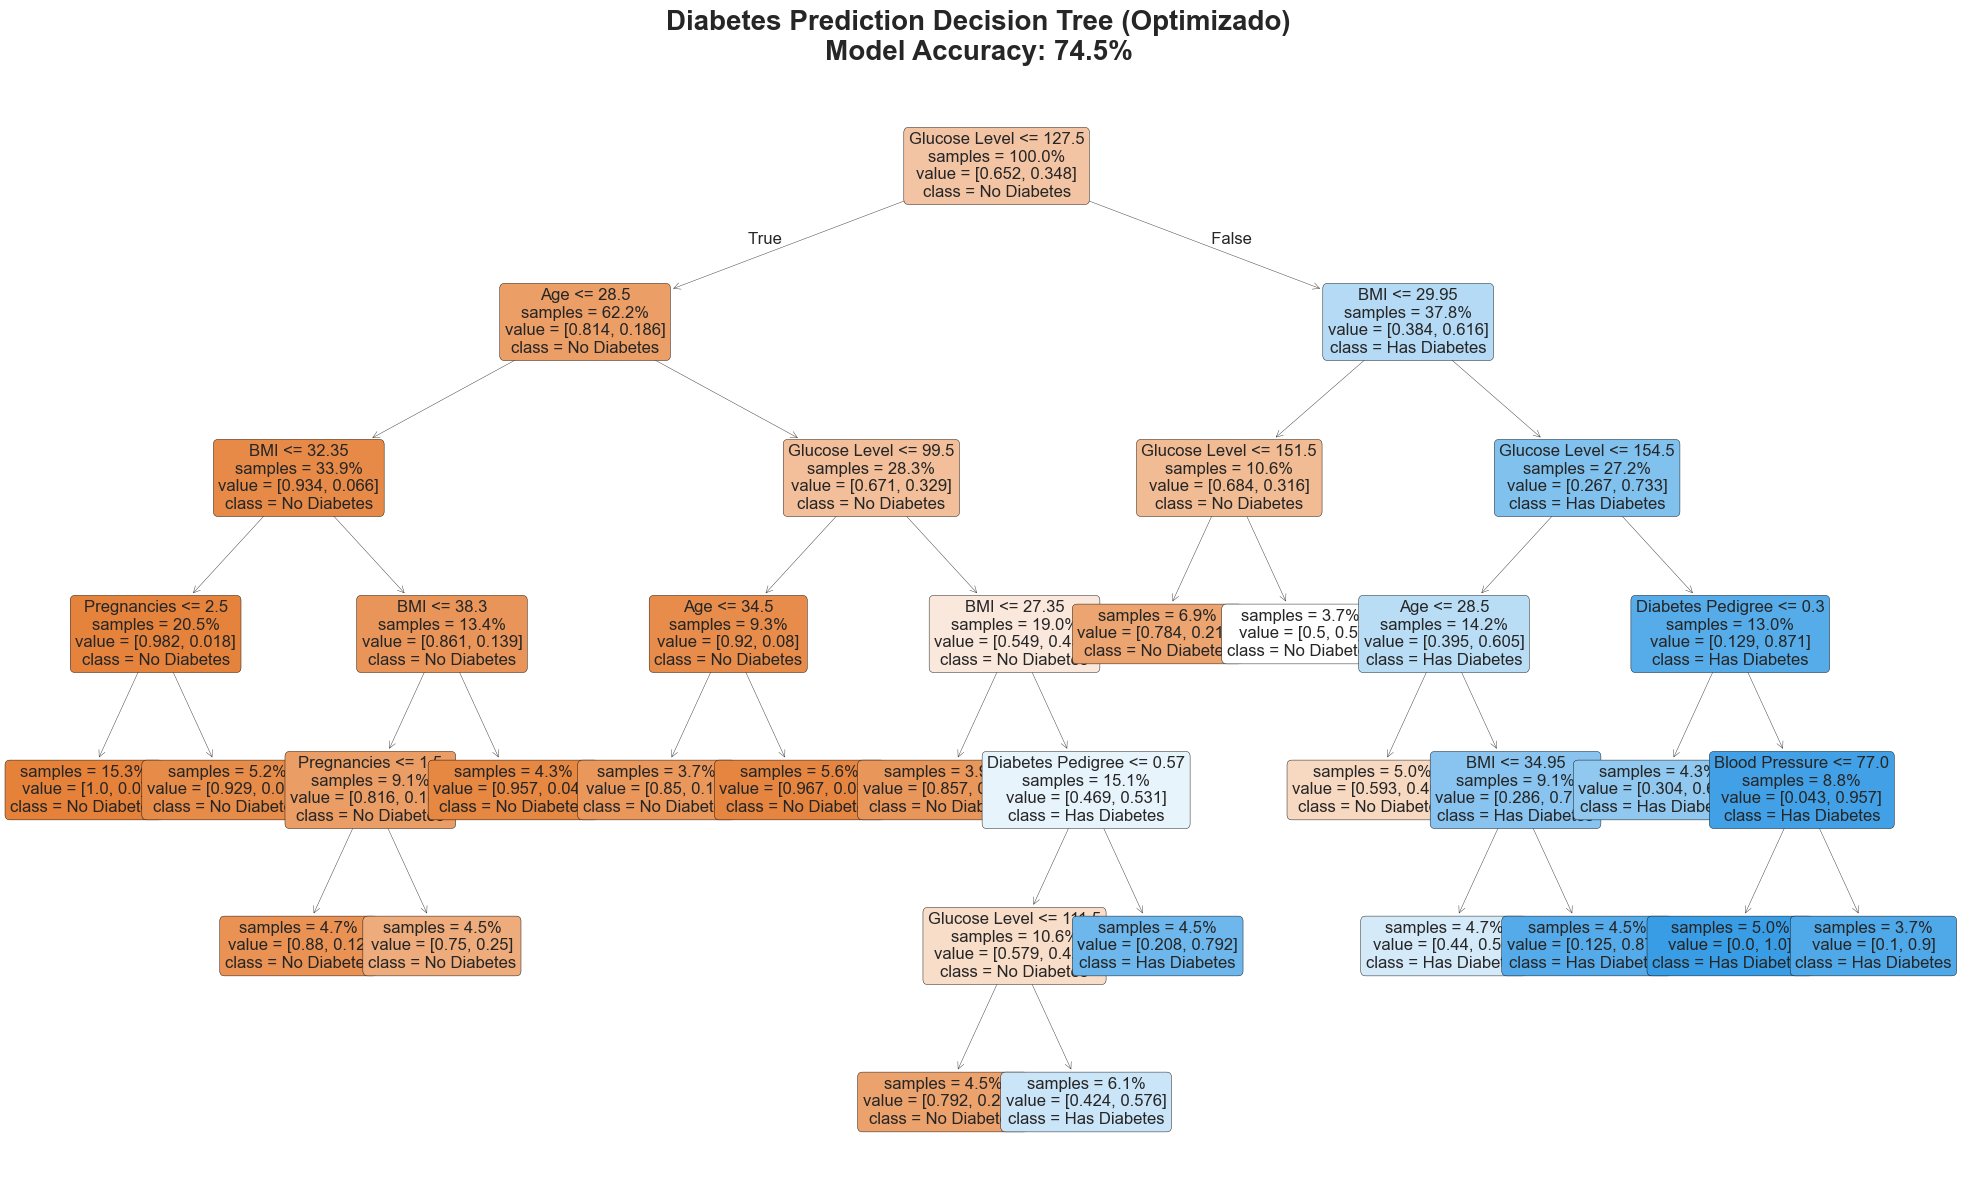

In [5]:
#################################  VISUALIZATION ####################################################

# 1. Beautiful Decision Tree Plot
plt.figure(figsize=(20, 12))
plot_tree(clf,
          feature_names=[feature_mapping[col] for col in feature_cols],
          class_names=['No Diabetes', 'Has Diabetes'],
          filled=True,
          rounded=True,
          fontsize=12,
          proportion=True,
          impurity=False)

plt.title('Diabetes Prediction Decision Tree (Optimizado)\n'
          f'Model Accuracy: {accuracy:.1%}',
          fontsize=20, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('friendly_decision_tree.png', dpi=300, bbox_inches='tight')
plt.show()


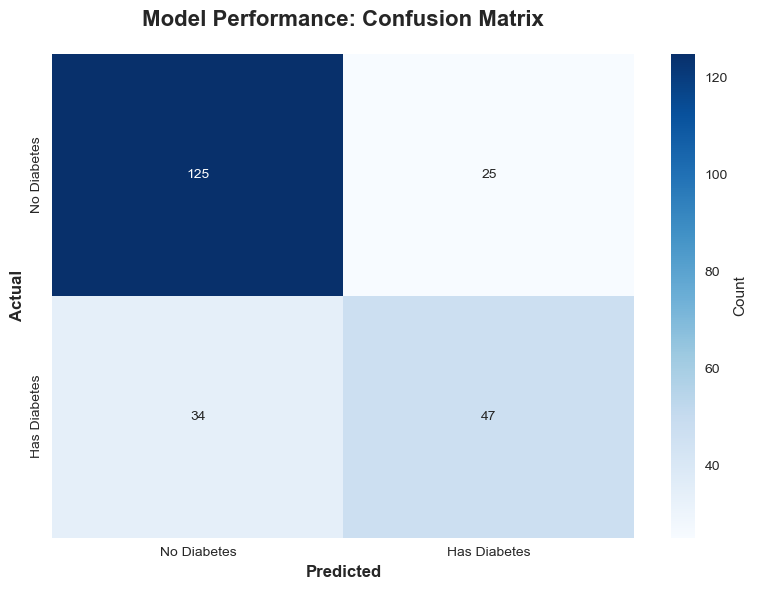

In [6]:
# 2. Model Performance Visualization

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Diabetes', 'Has Diabetes'],
            yticklabels=['No Diabetes', 'Has Diabetes'],
            cbar_kws={'label': 'Count'})
plt.title('Model Performance: Confusion Matrix', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Predicted', fontsize=12, fontweight='bold')
plt.ylabel('Actual', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()


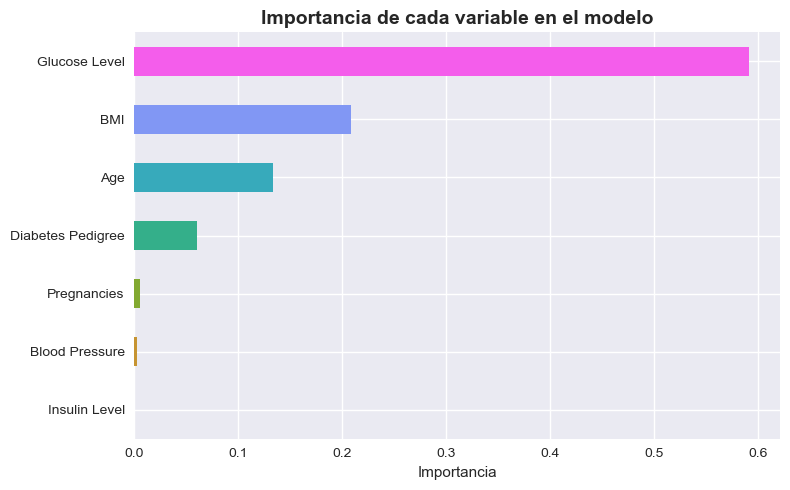

In [7]:
# 3. Importancia de caracteristicas
importances = pd.Series(clf.feature_importances_, index=[feature_mapping[c] for c in feature_cols])
importances = importances.sort_values(ascending=True)

plt.figure(figsize=(8, 5))
importances.plot(kind='barh', color=sns.color_palette("husl", len(importances)))
plt.title('Importancia de cada variable en el modelo', fontsize=14, fontweight='bold')
plt.xlabel('Importancia')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()


In [8]:
# 4. Summary Statistics
print("\n" + "="*60)
print("MODEL SUMMARY")
print("="*60)
print(f"Mejores hiperparametros: {grid_search.best_params_}")
print(f"Accuracy (test set): {accuracy:.1%}")
print(f"Accuracy (cross-validation, 5-fold): {cv_scores.mean():.1%} (+/- {cv_scores.std():.1%})")
print(f"Tree Depth: {clf.tree_.max_depth}")
print(f"Number of Leaves: {clf.tree_.n_leaves}")
print(f"Total Samples: {len(X)}")
print(f"Test Samples: {len(X_test)}")

# 5. Classification report
print("\nDetailed Classification Report:")
print(classification_report(y_test, y_pred, target_names=['No Diabetes', 'Has Diabetes']))



MODEL SUMMARY
Mejores hiperparametros: {'class_weight': None, 'criterion': 'gini', 'max_depth': 6, 'min_samples_leaf': 20, 'min_samples_split': 2}
Accuracy (test set): 74.5%
Accuracy (cross-validation, 5-fold): 75.4% (+/- 3.6%)
Tree Depth: 6
Number of Leaves: 19
Total Samples: 768
Test Samples: 231

Detailed Classification Report:
              precision    recall  f1-score   support

 No Diabetes       0.79      0.83      0.81       150
Has Diabetes       0.65      0.58      0.61        81

    accuracy                           0.74       231
   macro avg       0.72      0.71      0.71       231
weighted avg       0.74      0.74      0.74       231

